# Continuous Batching: Maximizing GPU Utilization in LLM Serving

> **Difficulty:** Beginner | **Time:** ~30 min

When serving an LLM to many users, requests arrive with different prompt lengths and generate different output lengths. **Static batching** groups requests into fixed batches — but short requests must wait for long ones to finish, wasting GPU cycles on padding.

**Continuous batching** (also called iteration-level batching or in-flight batching) solves this: at every decode step, completed requests are evicted and new requests fill their slots immediately.

This notebook covers:
1. Static batching and its padding waste
2. Continuous batching mechanics
3. Throughput and latency comparison
4. Prefill vs decode scheduling (chunked prefill)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference import (
    InferenceRequest, simulate_static_batching, simulate_continuous_batching,
)
from mp_tutorial.inference_viz import draw_batching_timeline, draw_prefill_decode_comparison
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

## 1. Static Batching: The Padding Problem

In **static batching**, a fixed set of requests is batched together. The batch runs until the **longest** request finishes — shorter requests sit idle (padded), wasting GPU compute.

```
Time →   0   1   2   3   4   5   6   7   8   9
Req 0:  [=] [=] [=] [·] [·] [·] [·] [·] [·] [·]  ← done at step 3, padding for 7 steps
Req 1:  [=] [=] [=] [=] [=] [=] [=] [=] [=] [=]  ← finishes at step 10
Req 2:  [=] [=] [=] [=] [=] [·] [·] [·] [·] [·]  ← done at step 5, padding for 5 steps
```

Static Batching (batch_size=4):
  Total time steps: 10
  Total slots used: 40
  Useful compute:   20 (50%)
  Padding waste:    20 (50%)


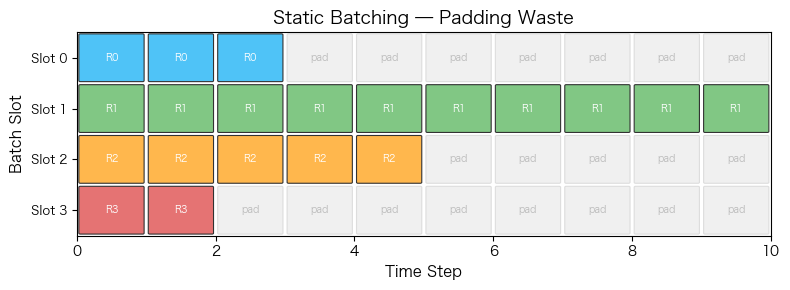

In [2]:
# Create requests with varying output lengths
requests_static = [
    InferenceRequest(request_id=0, prompt_len=10, output_len=3),
    InferenceRequest(request_id=1, prompt_len=10, output_len=10),
    InferenceRequest(request_id=2, prompt_len=10, output_len=5),
    InferenceRequest(request_id=3, prompt_len=10, output_len=2),
]

timeline_static = simulate_static_batching(requests_static, max_batch_size=4)

# Count waste
total_slots = sum(len(step[1]) for step in timeline_static)
padding_slots = sum(sum(1 for _, is_pad in step[1] if is_pad) for step in timeline_static)
useful_slots = total_slots - padding_slots

print(f"Static Batching (batch_size=4):")
print(f"  Total time steps: {len(timeline_static)}")
print(f"  Total slots used: {total_slots}")
print(f"  Useful compute:   {useful_slots} ({useful_slots/total_slots:.0%})")
print(f"  Padding waste:    {padding_slots} ({padding_slots/total_slots:.0%})")

fig, ax = draw_batching_timeline(timeline_static, title="Static Batching — Padding Waste")
plt.show()

---
## 2. Continuous Batching: Fill Slots Immediately

In **continuous batching**, the scheduler checks after every decode step:
1. **Evict** any completed requests from the batch
2. **Admit** waiting requests into the freed slots

No request ever sits idle — every batch slot is always doing useful work.

Continuous Batching (batch_size=4, 7 requests):
  Total time steps: 11
  Total slots used: 33
  Useful compute:   33 (100%)
  Padding waste:    0 (0%)


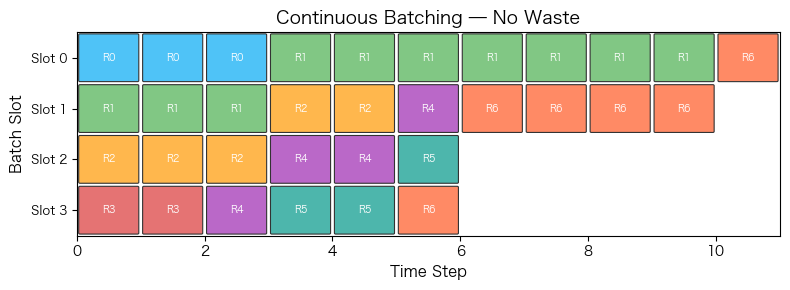

In [3]:
# Same requests, now with continuous batching
# We need fresh request copies since simulate mutates them
requests_cont = [
    InferenceRequest(request_id=0, prompt_len=10, output_len=3, arrival_time=0),
    InferenceRequest(request_id=1, prompt_len=10, output_len=10, arrival_time=0),
    InferenceRequest(request_id=2, prompt_len=10, output_len=5, arrival_time=0),
    InferenceRequest(request_id=3, prompt_len=10, output_len=2, arrival_time=0),
    # New requests arriving later
    InferenceRequest(request_id=4, prompt_len=10, output_len=4, arrival_time=2),
    InferenceRequest(request_id=5, prompt_len=10, output_len=3, arrival_time=3),
    InferenceRequest(request_id=6, prompt_len=10, output_len=6, arrival_time=4),
]

timeline_cont = simulate_continuous_batching(requests_cont, max_batch_size=4)

total_slots_c = sum(len(step[1]) for step in timeline_cont)
padding_slots_c = sum(sum(1 for _, is_pad in step[1] if is_pad) for step in timeline_cont)

print(f"Continuous Batching (batch_size=4, 7 requests):")
print(f"  Total time steps: {len(timeline_cont)}")
print(f"  Total slots used: {total_slots_c}")
print(f"  Useful compute:   {total_slots_c - padding_slots_c} ({(total_slots_c - padding_slots_c)/total_slots_c:.0%})")
print(f"  Padding waste:    {padding_slots_c} ({padding_slots_c/total_slots_c:.0%})")

fig, ax = draw_batching_timeline(timeline_cont, title="Continuous Batching — No Waste")
plt.show()

In [4]:
# Throughput comparison: static vs continuous with a realistic workload
import random
random.seed(42)

n_requests = 20
max_batch = 4

# Generate requests with varied output lengths (power-law distribution)
def make_requests(n, for_continuous=False):
    reqs = []
    for i in range(n):
        output_len = random.choice([2, 3, 4, 5, 8, 10, 15, 20])
        arrival = i // max_batch if not for_continuous else i  # stagger arrivals
        reqs.append(InferenceRequest(
            request_id=i, prompt_len=10, output_len=output_len,
            arrival_time=0 if not for_continuous else max(0, i - max_batch)
        ))
    return reqs

# Static batching
reqs_s = make_requests(n_requests)
tl_s = simulate_static_batching(reqs_s, max_batch)
total_time_s = len(tl_s)
total_tokens_s = sum(r.output_len for r in reqs_s)

# Continuous batching
reqs_c = make_requests(n_requests, for_continuous=True)
tl_c = simulate_continuous_batching(reqs_c, max_batch)
total_time_c = len(tl_c)
total_tokens_c = sum(r.output_len for r in reqs_c)

print(f"Workload: {n_requests} requests, batch_size={max_batch}")
print(f"Total tokens to generate: {total_tokens_s}\n")

print(f"{'Metric':<25} | {'Static':>10} | {'Continuous':>10}")
print("-" * 50)
print(f"{'Total time steps':<25} | {total_time_s:>10} | {total_time_c:>10}")
print(f"{'Throughput (tok/step)':<25} | {total_tokens_s/total_time_s:>10.2f} | {total_tokens_c/total_time_c:>10.2f}")
print(f"{'Avg latency (steps)':<25} | {np.mean([r.end_time - r.start_time for r in reqs_s if r.end_time]):>10.1f} | {np.mean([r.end_time - r.start_time for r in reqs_c if r.end_time]):>10.1f}")

print(f"\n→ Continuous batching: {total_tokens_c/total_time_c / (total_tokens_s/total_time_s):.1f}× higher throughput")

Workload: 20 requests, batch_size=4
Total tokens to generate: 120

Metric                    |     Static | Continuous
--------------------------------------------------
Total time steps          |         53 |         48
Throughput (tok/step)     |       2.26 |       3.19
Avg latency (steps)       |       10.6 |        7.7

→ Continuous batching: 1.4× higher throughput


---
## 3. Prefill vs Decode Scheduling

In a continuous batching system, two types of work compete for GPU time:

| Phase | Compute Profile | Latency Sensitivity |
|-------|----------------|--------------------|
| **Prefill** | Compute-bound, high GPU utilization | Time-to-first-token (TTFT) |
| **Decode** | Memory-bound, low GPU utilization | Inter-token latency (ITL) |

The problem: if a new request starts prefilling (processing a long prompt), it can **stall** ongoing decode requests, causing latency spikes.

### Chunked Prefill

Solution: break prefill into **chunks** and interleave with decode steps.

```
Without chunked prefill:       With chunked prefill:
  [PPPPPPPP][DDDDDDDD]          [PP][DD][PP][DD][PP][DD][PP][DD]
  ↑ decode stalls here           ↑ decode continues between chunks
```

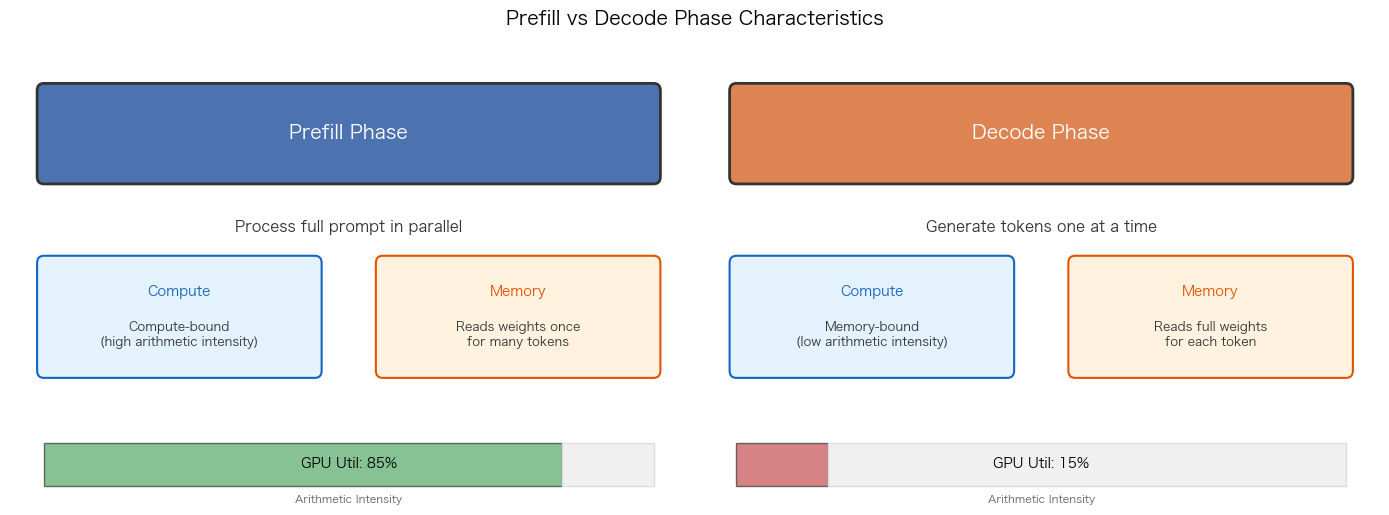

In [5]:
# Visualize prefill vs decode phases
fig, axes = draw_prefill_decode_comparison(title="Prefill vs Decode Phase Characteristics")
plt.show()

In [6]:
# Simulate chunked vs unchunked prefill impact on decode latency
prompt_len = 1024  # tokens to prefill
decode_batch = 8   # ongoing decode requests
chunk_size = 128   # prefill chunk size

# Without chunking: prefill blocks all decode
unchunked_decode_stall = prompt_len  # decode waits for full prefill

# With chunking: decode runs between chunks
n_chunks = prompt_len // chunk_size
chunked_max_stall = chunk_size  # max stall is one chunk

print(f"New request with {prompt_len}-token prompt")
print(f"{decode_batch} ongoing decode requests\n")
print(f"{'Strategy':<25} | {'Max decode stall':>16} | {'Prefill chunks':>14}")
print("-" * 60)
print(f"{'Unchunked prefill':<25} | {unchunked_decode_stall:>13} ms* | {'1 (full)':>14}")
print(f"{'Chunked (size=128)':<25} | {chunked_max_stall:>13} ms* | {n_chunks:>14}")
print(f"{'Chunked (size=64)':<25} | {64:>13} ms* | {prompt_len//64:>14}")
print(f"\n*proportional to tokens processed; actual ms depends on hardware")
print(f"\n→ Chunked prefill reduces worst-case decode stall by {unchunked_decode_stall/chunked_max_stall:.0f}×")

New request with 1024-token prompt
8 ongoing decode requests

Strategy                  | Max decode stall | Prefill chunks
------------------------------------------------------------
Unchunked prefill         |          1024 ms* |       1 (full)
Chunked (size=128)        |           128 ms* |              8
Chunked (size=64)         |            64 ms* |             16

*proportional to tokens processed; actual ms depends on hardware

→ Chunked prefill reduces worst-case decode stall by 8×


---
## Summary

| Strategy | How It Works | GPU Utilization | Latency |
|----------|-------------|----------------|---------|
| **Static batching** | Fixed batch, pad to longest | Low (padding waste) | High (wait for slowest) |
| **Continuous batching** | Evict + admit each step | High (no padding) | Low (no waiting) |
| **Chunked prefill** | Break prefill into chunks | Balanced | Predictable decode latency |

Continuous batching is used by all modern LLM serving systems:
- **vLLM** — iteration-level scheduling with PagedAttention
- **TGI** (Text Generation Inference) — continuous batching
- **TensorRT-LLM** — in-flight batching

### Further Reading
- [Orca: A Distributed Serving System for Transformer-Based Generative Models (Yu et al., 2022)](https://www.usenix.org/conference/osdi22/presentation/yu)
- [Efficient Memory Management for Large Language Model Serving with PagedAttention (Kwon et al., 2023)](https://arxiv.org/abs/2309.06180)
- Next notebook: **[03-paged-attention](03-paged-attention.ipynb)** — solving the KV-cache memory management problem